In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/home/brendan/OneDrive/Masters/Code/Vortices/Julia/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from jax.lib import xla_bridge
import jax
print(xla_bridge.get_backend().platform)
# name = "cuDNN"
jax._src.lib.cuda_versions.cudnn_get_version()
# jax._src.lib.cuda_versions.cudnn_build_version()
jax.default_device = jax.devices("gpu")[0]
# bp.math.set_platform("gpu")

gpu


In [ ]:
# bp.math.set_dt(0.05) # Check sims look similar with smaller timestep

# Shencong Parameters
delta = 0.007 # Grid spacing
dx = 64*delta # Originally 64*delta # 64 x 64 integer grid, 7um spacing
rho = 20000
p_ee = 0.4 #0.8 # These have been tweaked in order to match the mean sum of weights without explicitly setting between-population weight strengths
p_ei = 0.35 #0.7
p_ie = 0.2 #0.4
p_ii = 0.29 #0.57
sigma_ee = 7.5*delta
sigma_ei = 9.5*delta
sigma_ie = 19*delta
sigma_ii = 19*delta
kernel = src.models.FNS.ExponentialKernel

J_e = 0.0008 # Microsiemens, which is a bit high for realism. In spontaneous simulation code. Different from main paper. Corresponds directly to w_ee


zeta = 4
nu = 10
n_ext = 55# 200

# These parameters don't match shencong exactly, because of the strange definition of
# synaptic weight. But they should result in proportional weights and similar dynamcis

In [4]:
from src.models.FNS import FNScircuit
# * Construct, takes around 3 minutes
FNSnet = FNScircuit(rho = rho, dx=dx, J_e = J_e,
        nu = nu, n_ext = n_ext, zeta=zeta,
        p_ee=p_ee,
        p_ei=p_ei,
        p_ie=p_ie,
        p_ii=p_ii,
        sigma_ee=sigma_ee,
        sigma_ei=sigma_ei,
        sigma_ie=sigma_ie,
        sigma_ii=sigma_ii,
        kernel=kernel,
        key=jax.random.PRNGKey(42))
# ! Chosen these parameters based on layer 2/3 connectivity parameters found via https://aisynphys.readthedocs.io/en/latest/matrix_analyzer.html#matrix-analyzer
# For biological plausability, n_ext should be about 10% of the in-degree and nu should be
# ? Note that around 10% of synapses tend to be external feed-forward... check... cite...
# no more than a dozen or so???
# FNSnet = FNScircuit(rho=30000, nu=275.0, n_ext = 30, J_e=0.0005, zeta=18)


/home/brendan/OneDrive/Masters/Code/Vortices/Julia/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


In [5]:
# FNSnet.get_input_params()
# model = FNSnet.update_copy(J_e=0.0)

In [6]:
# bp.odeint(FNSnet.E.dV, show_code=True)
# bp.odeint(bp.JointEq([FNSnet.E.dV, FNSnet.E.dg_K]), show_code=True)

In [7]:
print("Num. Exc.:");print(np.prod(FNSnet.E.size))
print("Num. Inh.:");print(np.prod(FNSnet.I.size))

Num. Exc.:
3969
Num. Inh.:
992


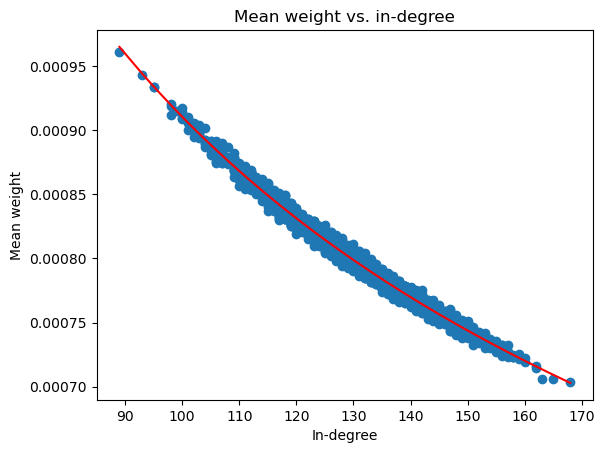

E2E in-degree: 129.4 (mean), 138.5 (gaussian expected)
E2I in-degree: 170.3 (mean), 194.5 (gaussian expected)
I2E in-degree: 61.4 (mean), 111.1 (gaussian expected)
I2I in-degree: 89.5 (mean), 161.2 (gaussian expected)
External in-degree (Exc.): 54.9 (mean)
External in-degree (Inh.): 54.6 (mean)


In [8]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(FNSnet.E2E.proj)
ks = src.models.FNS.indegrees(FNSnet.E2E.proj)
plt.scatter(ks, mean_ws)
a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
sks = np.sort(ks)
plt.plot(sks, a/np.sqrt(sks) + b, 'r')
plt.xlabel('In-degree')
plt.ylabel('Mean weight')
plt.title('Mean weight vs. in-degree')
plt.show()


k = src.models.FNS.indegree(FNSnet.E2E.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ee")
print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.models.FNS.indegree(FNSnet.E2I.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ei")
print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.models.FNS.indegree(FNSnet.I2E.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ie")
print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.models.FNS.indegree(FNSnet.I2I.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ii")
print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")

# Print the mean number of external synapses
k_ext = src.models.FNS.indegree(FNSnet.ext2E.proj)
print(f"External in-degree (Exc.): {k_ext:.1f} (mean)")
k_ext = src.models.FNS.indegree(FNSnet.ext2I.proj)
print(f"External in-degree (Inh.): {k_ext:.1f} (mean)")

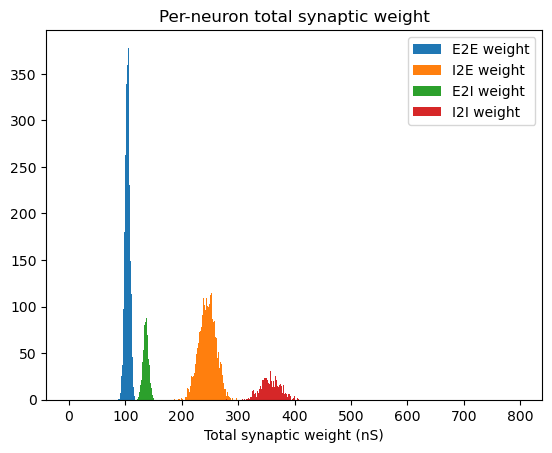

Sum of weights to average neuron:
E2E: 103.54589147655268 (nS)
E2I: 136.1939631822738 (nS)
I2E: 245.7398767150731 (nS)
I2I: 357.8529476827469 (nS)


In [9]:
FNSnet.reinit_weights(zeta)
FNSnet.reinit_nu(nu)
bp.reset_state(FNSnet) # Resets all things recursively, unlike FNSnet.reset_state()


# * Calculate the per-neuron EI balance
# DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
# ? How to peroperly check the balance of weights?
I2E = bp.connect.csr2coo((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr))
E2E = bp.connect.csr2coo((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr))
E2I = bp.connect.csr2coo((FNSnet.E2I.proj.comm.indices, FNSnet.E2I.proj.comm.indptr))
I2I = bp.connect.csr2coo((FNSnet.I2I.proj.comm.indices, FNSnet.I2I.proj.comm.indptr))
w_I2E = FNSnet.I2E.proj.comm.weight
w_E2E = FNSnet.E2E.proj.comm.weight
w_E2I = FNSnet.E2I.proj.comm.weight
w_I2I = FNSnet.I2I.proj.comm.weight
assert len(I2E[0]) == len(w_I2E)

Ne = np.prod(FNSnet.E.size)
Ni = np.prod(FNSnet.I.size)
bin_w_E2E = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
bin_w_I2E = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
bin_w_E2I = np.bincount(E2I[1], weights=w_E2I, minlength=Ni)
bin_w_I2I = np.bincount(I2I[1], weights=w_I2I, minlength=Ni)
bins = np.arange(0, 800, 1)
plt.hist(bin_w_E2E*1000, bins=bins, label="E2E weight")
plt.hist(bin_w_I2E*1000, bins=bins, label="I2E weight")
plt.hist(bin_w_E2I*1000, bins=bins, label="E2I weight")
plt.hist(bin_w_I2I*1000, bins=bins, label="I2I weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.xlabel("Total synaptic weight (nS)")
plt.show()

# plt.scatter(bin_w_E2E, bin_w_I2E)
# plt.show()

# plt.hist(bin_w_E2E/bin_w_I2E, bins=50)
# plt.show()

# * Print sum of weights in table
print("Sum of weights to average neuron:")
print("E2E:", np.mean(bin_w_E2E)*1000, "(nS)") # Should be approx 2100
print("E2I:", np.mean(bin_w_E2I)*1000, "(nS)") # approx 3800
print("I2E:", np.mean(bin_w_I2E)*1000, "(nS)") # 5800
print("I2I:", np.mean(bin_w_I2I)*1000, "(nS)") # 8100


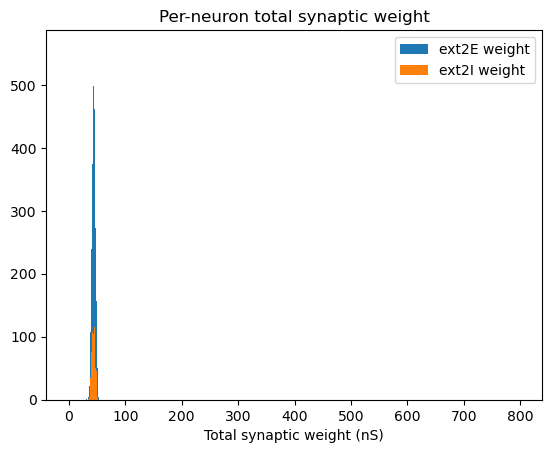

Sum of weights to average neuron (from external):
ext2E: 43.95401029446078 (nS)
ext2I: 43.68381513584961 (nS)


In [10]:
# * As previous cell, but for external pop
ext2E = bp.connect.csr2coo((FNSnet.ext2E.proj.comm.indices, FNSnet.ext2E.proj.comm.indptr))
ext2I = bp.connect.csr2coo((FNSnet.ext2I.proj.comm.indices, FNSnet.ext2I.proj.comm.indptr))
w_ext2E = FNSnet.ext2E.proj.comm.weight
w_ext2I = FNSnet.ext2I.proj.comm.weight
assert len(ext2E[0]) == len(w_ext2E)

bin_w_ext2E = np.bincount(ext2E[1], weights=w_ext2E, minlength=Ne)
bin_w_ext2I = np.bincount(ext2I[1], weights=w_ext2I, minlength=Ni)
plt.hist(bin_w_ext2E*1000, bins=bins, label="ext2E weight")
plt.hist(bin_w_ext2I*1000, bins=bins, label="ext2I weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.xlabel("Total synaptic weight (nS)")
plt.show()

# plt.scatter(bin_w_ext2E, bin_w_ext2I)
# plt.show()

# plt.hist(bin_w_ext2E/bin_w_ext2I, bins=50)
# plt.show()

print("Sum of weights to average neuron (from external):")
print("ext2E:", np.mean(bin_w_ext2E)*1000, "(nS)") # Should be approx 1000
print("ext2I:", np.mean(bin_w_ext2I)*1000, "(nS)") # approx 1000


In [11]:
FNSnet.reinit_weights(zeta)
FNSnet.reinit_nu(nu) # nu
bp.reset_state(FNSnet) # Resets all things recursively, unlike FNSnet.reset_state()

# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights

# * Simulate
I = np.array(FNSnet.E.V.value)
I[:] = 0.0
i = I.reshape(*FNSnet.E.size)
i[0:25, 0:25] = 0.0

runner = bp.DSRunner(FNSnet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike', 'E.g_K', 'I.g_K'])# , inputs = [('Ein.input', I)])
runner.run(duration=1000.)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

Predict 10000 steps: : 100%|██████████| 10000/10000 [00:05<00:00, 1938.69it/s]


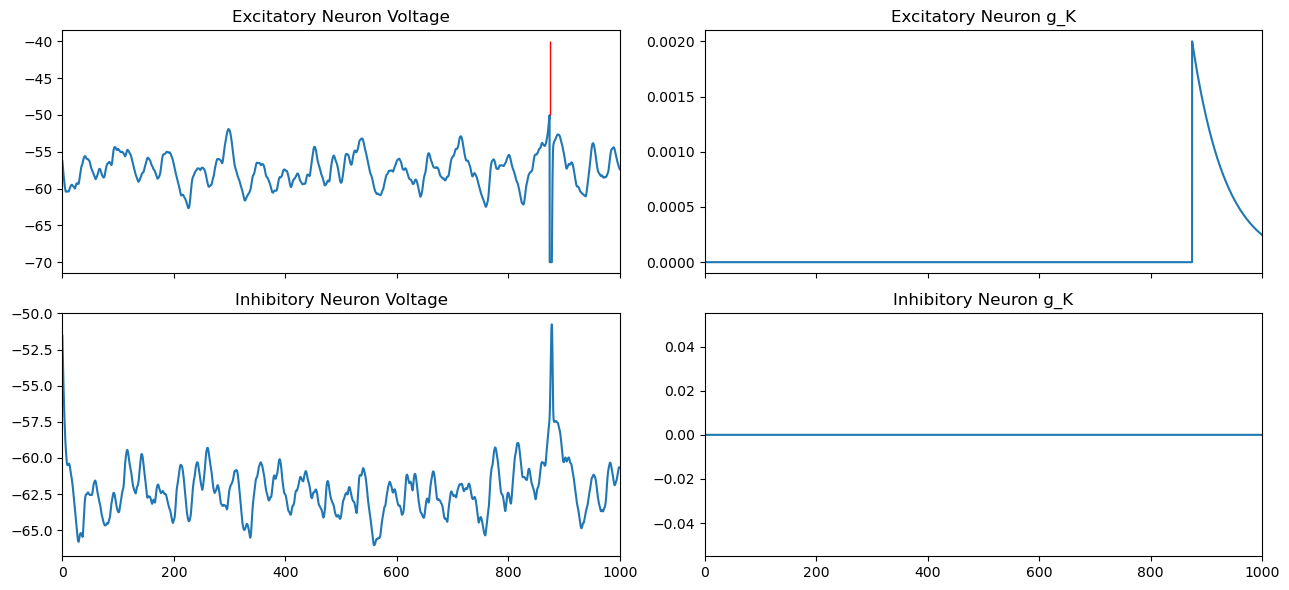

In [12]:
i = 10
fig, axs = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
x = runner.mon['E.V'].view()[:, i]
spikes = np.where(runner.mon['E.spike'].view()[:, i])
axs[0, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[0, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[0, 0].set_title('Excitatory Neuron Voltage')
x = runner.mon['I.V'].view()[:, i]
spikes = np.where(runner.mon['I.spike'].view()[:, i])
axs[1, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[1, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[1, 0].set_title('Inhibitory Neuron Voltage')

x = runner.mon['E.g_K'].view()[:, i]
axs[0, 1].plot(runner.mon['ts'].view(), x)
axs[0, 1].set_title('Excitatory Neuron g_K')

x = runner.mon['I.g_K'].view()[:, i]
axs[1, 1].plot(runner.mon['ts'].view(), x)
axs[1, 1].set_title('Inhibitory Neuron g_K')


plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

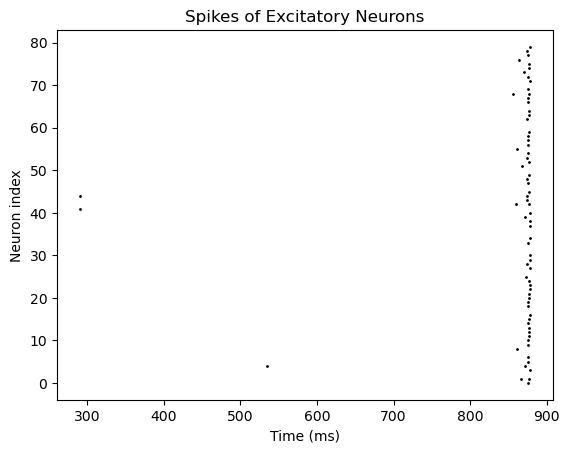

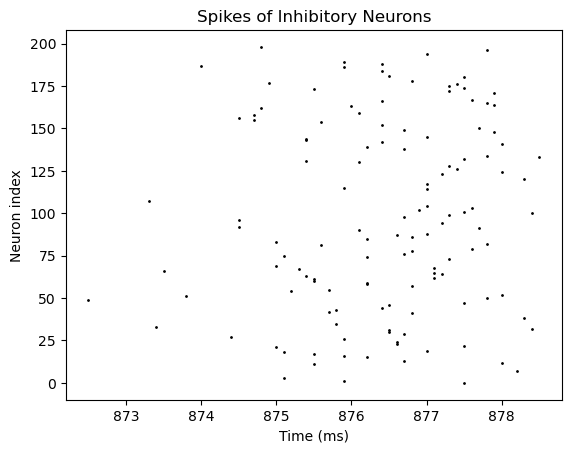

In [13]:
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::50],
                            title="Spikes of Excitatory Neurons")
plt.show()
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons")

In [14]:
# # * First, plot the current distribution of synaptic weights
# ws = FNSnet.E2E.proj.comm.weight
# plt.hist(ws, bins=50)
# plt.gca().set_title('E2E weights')

# # * And the number of synapses per neuron
# plt.figure()
# plt.hist(np.diff(FNSnet.E2E.proj.comm.indptr), bins=50) # ! Check !!!
# plt.gca().set_title('Number of synapses per neuron')
# plt.show()

In [ ]:
# bp.visualize.raster_plot(t, X, title='Spikes of Excitatory Neurons', show=True)
%matplotlib inline
from src.plots import animate_spiking_activity
from IPython.display import HTML
ani = animate_spiking_activity(FNSnet, runner, ms_per_s=100, fps=12, window_size_ms=50, tstart=0)

ani.save("spiking_activity.mp4", writer="ffmpeg")
# HTML(ani.to_jshtml())

In [ ]:
# import copy

# # * Try parallell simulation
# FNSnet.reinit_weights(85)
# FNSnet.reinit_nu(130)
# bp.reset_state(FNSnet) # Resets all things recursively, unlike FNSnet.reset_state()

# def model_array(model, Js, nus):
#     models = []
#     for J, nu in zip(Js, nus):
#         m = copy.deepcopy(model)
#         m.reinit_weights(J)
#         m.reinit_nu(nu)
#         models.append(m)
#     return models

# def run_model(model):
#     bp.reset_state(model) # Resets all things recursively, unlike FNSnet.reset_state()
#     runner = bp.DSRunner(FNSnet, monitors=['E.spike'])# , inputs = [('Ein.input', I)])
#     runner.run(duration=5000.)
#     return runner


# js = np.linspace(80, 90, 2)
# nus = np.full(js.shape, 130)
# all_params = zip(js, nus)
# bp.running.cpu_ordered_parallel(run_model, all_params, num_process=10)

In [ ]:
# @jax.jit
# def test():
#     FNSnet.reinit_nu(85)
#     return FNSnet.

# test()

In [ ]:
# @jax.jit
# def test_build():
#     other = FNScircuit(rho = rho, dx=dx, J_e = J_e,
#         nu = 2.5, n_ext = 25, zeta=4,
#         p_ee=p_ee,
#         p_ei=p_ei,
#         p_ie=p_ie,
#         p_ii=p_ii,
#         sigma_ee=sigma_ee,
#         sigma_ei=sigma_ei,
#         sigma_ie=sigma_ie,
#         sigma_ii=sigma_ii,
#         kernel=kernel,
#         key=jax.random.PRNGKey(42),
#         copy_conn=FNSnet) # Copy connectivity from the original circuit to avoid slow rebuilding
#     return other

# test_build()

In [ ]:
# other = FNScircuit(rho = rho, dx=dx, J_e = J_e,
#         nu = 2.5, n_ext = 25, zeta=4,
#         p_ee=p_ee,
#         p_ei=p_ei,
#         p_ie=p_ie,
#         p_ii=p_ii,
#         sigma_ee=sigma_ee,
#         sigma_ei=sigma_ei,
#         sigma_ie=sigma_ie,
#         sigma_ii=sigma_ii,
#         kernel=kernel,
#         key=jax.random.PRNGKey(42),
#         copy_conn=FNSnet) # COpy connectivity from the original circuit to avoid slow rebuilding
# other.reinit_nu(123)
# print(other.ext.freqs)
# print(FNSnet.ext.freqs) # SHould not match :)

In [ ]:
# params = {"rho" : rho, "dx":dx, "J_e" : J_e,
#         "nu" : 2.5, "n_ext" : 25, "zeta":4,
#         "p_ee":p_ee,
#         "p_ei":p_ei,
#         "p_ie":p_ie,
#         "p_ii":p_ii,
#         "sigma_ee":sigma_ee,
#         "sigma_ei":sigma_ei,
#         "sigma_ie":sigma_ie,
#         "sigma_ii":sigma_ii,
#         "kernel":kernel,
#         "key":jax.random.PRNGKey(42)}
# def copy_run(zeta, nu, model, duration=1000., monitors=['E.spike']):
#     new_model = model.update_copy(zeta=zeta, nu=nu)
#     runner = bp.DSRunner(model, monitors=monitors)
#     runner.run(duration=duration)
#     return runner

# nus = np.linspace(120, 140, 2)
# zetas = np.linspace(80, 90, 2)
# # models = [copy_model(j, 130, FNSnet, params) for j in js]
# bp.running.cpu_unordered_parallel(copy_run, [zetas, nus, [FNSnet]], num_process=10)


In [ ]:
# def run(model, duration=1000., monitors=['E.spike']):
#     runner = bp.DSRunner(model, monitors=monitors)
#     runner.run(duration=duration)
#     return runner


In [ ]:
# FNSnet